# 00. LGD(Loss Given Default) 추정

## 왜 필요한가

이 프로젝트의 핵심 공식은 다음과 같습니다.

**EL(기대손실) = PD × LGD × EAD**

여기서 LGD가 불투명하면 담보 유형과 회수 절차별 손실률 차이를 반영할 수 없어 EL 계산과 대출 한도 산정의 정밀도가 떨어집니다. 그 결과 저위험 차주에는 과도하게 보수적이고 고위험 차주에는 과도하게 관대한 정책이 나올 수 있어, 정밀한 정책 설계와 시뮬레이션을 위해 LGD 추정 절차가 필요합니다.

## 문제: 이 데이터셋에는 LGD를 직접 알려주는 피처가 없다

Home Credit Default Risk 데이터셋에는 부도 후 회수 금액을 직접 나타내는 컬럼이 없어 LGD를 바로 관측할 수 없습니다. 이 경우 LGD를 다루는 방법은 보통 세 가지로 나뉩니다.

1. **시장 데이터 기반(Market LGD)**: 부도 채권의 시장 거래가로 역산 → 소비자 대출은 시장 자체가 없어 적용 불가
2. **Workout LGD**: 부도 발생 후 실제 회수 과정(월별 회수액, 담보 처분액 등)을 추적 → 이 데이터셋에 회수 이력 자체가 없음
3. **업계 기준값 적용**: 바젤 III 등 규제 기준의 표준 LGD를 사용

이 노트북은 1), 2)번을 이 데이터셋 안에서 우회적으로라도 근사할 수 있는지 — 즉 **LGD proxy로 사용할 수 있는 피처 조합**이 존재하는지를 단계적으로 검증하고, 그 결과에 따라 최종 LGD 기본값을 채택하는 과정을 담습니다.

## Step 1. bureau.csv 전체 차주 대상 LGD proxy 계산

가장 먼저 잔존 부채 비율, 즉 현재 남은 부채를 원래 대출 금액으로 나눈 값을 계산해 LGD proxy로 검토했습니다. 부도 후 회수 데이터가 없기 때문에, 아직 상환되지 않은 비율이 높을수록 손실도 클 것이라는 가정 하에 1차 근사치로 사용했습니다.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

bureau = pd.read_csv('../data/bureau.csv')

# LGD proxy = 현재 미상환 부채 / 원래 대출 금액
# LGD proxy 값이 0 ~ 1 사이에 포함된 값만 출력
bureau['lgd_proxy'] = bureau['AMT_CREDIT_SUM_DEBT'] / bureau['AMT_CREDIT_SUM']
lgd_valid = bureau['lgd_proxy'].dropna()
lgd_valid = lgd_valid[(lgd_valid >= 0) & (lgd_valid <= 1)]

print(f"LGD proxy 중앙값: {lgd_valid.median():.2f}")
print(f"LGD proxy 평균:   {lgd_valid.mean():.2f}")
print(f"LGD proxy 75th:   {lgd_valid.quantile(0.75):.2f}")

LGD proxy 중앙값: 0.00
LGD proxy 평균:   0.20
LGD proxy 75th:   0.33


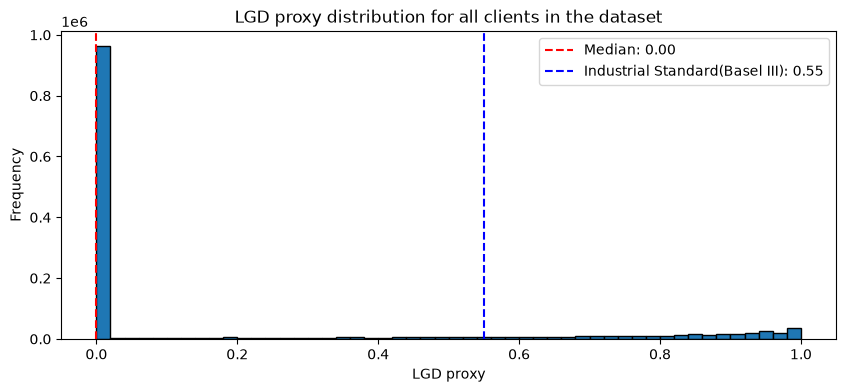

In [3]:
plt.figure(figsize=(10, 4))
plt.hist(lgd_valid, bins=50, edgecolor='black')
plt.axvline(lgd_valid.median(), color='red',
            linestyle='--', label=f'Median: {lgd_valid.median():.2f}')
plt.axvline(0.55, color='blue',
            linestyle='--', label='Industrial Standard(Basel III): 0.55')
plt.title('LGD proxy distribution for all clients in the dataset')
plt.xlabel('LGD proxy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 결과 해석

**LGD는 부도 발생 후 손실률**이므로, 부도와 무관한 전체 표본에서 계산한 값은 LGD를 대변하기 어렵습니다. bureau.csv는 모든 외부 대출 이력을 포함해 상환이 완료된 대출이 다수를 차지하므로, 전체 차주를 기준으로 하면 잔존 부채 비율이 0에 수렴해 LGD 신호가 희석됩니다. 따라서 LGD를 더 타당하게 근사하려면 표본을 최소한 부도 경험자로 좁혀야 합니다.

## Step 2. 부도 경험자(TARGET=1)로 표본 좁히기

application_train에서 부도 고객만 추출한 뒤 이들의 bureau 기록을 바탕으로 LGD proxy를 재산출합니다.

In [4]:
# 이전 방식: 전체 고객 대상 LGD proxy (AMT_CREDIT_SUM_DEBT / AMT_CREDIT_SUM)
# 바뀐 방식: 부도 고객 필터링 -> 부도 고객 대상 LGD proxy 계산

app = pd.read_csv('../data/application_train.csv')
defaulted_ids = app[app['TARGET'] == 1]['SK_ID_CURR']
print(f"부도 경험자 수: {len(defaulted_ids)}")
print(f"전체 대비 비율: {len(defaulted_ids)/len(app):.2%}")

bureau_defaulted = bureau[bureau['SK_ID_CURR'].isin(defaulted_ids)]
print(f"\n부도 경험자 bureau 레코드 수: {len(bureau_defaulted)}")

print("\nCREDIT_ACTIVE 분포 (부도 경험자):")
print(bureau_defaulted['CREDIT_ACTIVE'].value_counts())

bureau_defaulted = bureau_defaulted.copy()
bureau_defaulted['lgd_proxy'] = (
    bureau_defaulted['AMT_CREDIT_SUM_DEBT'] /
    bureau_defaulted['AMT_CREDIT_SUM']
)
lgd_defaulted = bureau_defaulted['lgd_proxy'].dropna()
lgd_defaulted = lgd_defaulted[(lgd_defaulted >= 0) & (lgd_defaulted <= 1)]

print(f"\n부도 경험자 LGD proxy:")
print(f"중앙값: {lgd_defaulted.median():.2f}")
print(f"평균:   {lgd_defaulted.mean():.2f}")
print(f"75th:   {lgd_defaulted.quantile(0.75):.2f}")
print(f"90th:   {lgd_defaulted.quantile(0.90):.2f}")

부도 경험자 수: 24825
전체 대비 비율: 8.07%

부도 경험자 bureau 레코드 수: 114520

CREDIT_ACTIVE 분포 (부도 경험자):
CREDIT_ACTIVE
Closed      63609
Active      50336
Sold          571
Bad debt        4
Name: count, dtype: int64

부도 경험자 LGD proxy:
중앙값: 0.00
평균:   0.26
75th:   0.67
90th:   0.94


### 결과 해석

부도 경험자 대상 `CREDIT_ACTIVE` 분포를 보면 `Closed`가 가장 많습니다. 이는 부도가 차주 전체가 아니라 **특정 시점의 개별 대출에서 발생하는 사건**이기 때문입니다. 따라서 부도 경험자라고 해서 모든 대출이 부실한 것은 아니며, 이전에 정상 상환된 대출은 여전히 `Closed`로 집계됩니다.

그리고 `Bad debt` 부실 확정 사례가 4건으로 매우 적은 것은 외부 신용기관 CB 데이터라는 관측 구조의 제약으로 해석하는 편이 타당합니다. 자체 대출에서 발생한 부도가 외부 CB 라벨에 Bad debt으로 일관되게 반영되기 어렵고, Home Credit의 비금융 고객군 특성상 CB 기록이 충분히 축적되지 않았을 가능성이 높기 때문입니다.

따라서 이후 분석은 현재 진행 중인 `Active` 대출만 대상으로 신호를 재검토합니다.

## Step 3. 부도 경험자의 Active 대출만 필터링

In [5]:
# 이전 방식: 부도 경험자의 전체 대출 케이스 기반 LGD Proxy
# 바뀐 방식: 부도 경험자들의 'Active' 케이스 기반 LGD Proxy 계산
bureau_defaulted_active = bureau_defaulted[
    bureau_defaulted['CREDIT_ACTIVE'] == 'Active'
].copy()

bureau_defaulted_active['lgd_proxy'] = (
    bureau_defaulted_active['AMT_CREDIT_SUM_DEBT'] /
    bureau_defaulted_active['AMT_CREDIT_SUM']
)

lgd_active = bureau_defaulted_active['lgd_proxy'].dropna()
lgd_active = lgd_active[(lgd_active >= 0) & (lgd_active <= 1)]

print("부도 경험자 Active 대출 LGD proxy:")
print(f"중앙값: {lgd_active.median():.2f}")
print(f"평균:   {lgd_active.mean():.2f}")
print(f"75th:   {lgd_active.quantile(0.75):.2f}")

부도 경험자 Active 대출 LGD proxy:
중앙값: 0.79
평균:   0.63
75th:   0.94


### 결과 해석

중앙값은 0.79로 크게 상승했지만, `CREDIT_ACTIVE` = `Active`가 실제 잔액 보유 대출을 정확히 대표하는지는 아직 검증되지 않았습니다. 따라서 `bureau_balance.csv`의 월별 잔액 기록을 통해 이 상태 라벨의 타당성을 교차 검증했습니다.

## Step 4. bureau_balance로 Active 대출의 실제 잔액 상태 검증

In [7]:
# 이전 방식: 부도 경험자들의 CREDIT_ACTIVE = Active 케이스의 LGD Proxy 계산
# 중앙값이 0.79가 나옴, Active가 정말 잔액 보유 대출을 의미하는지 확인 필요
# 바뀐 방식: Active 대출의 잔액 보유 대출 검증
# STATUS: 0 = 잔액 없음, 1 ~ 5 = 연체 개월수, C = 상환 완료, X = 정보 없음

bureau_balance = pd.read_csv('../data/bureau_balance.csv')

active_bureau_ids = bureau_defaulted[
    bureau_defaulted['CREDIT_ACTIVE'] == 'Active'
]['SK_ID_BUREAU']

balance_active = bureau_balance[
    bureau_balance['SK_ID_BUREAU'].isin(active_bureau_ids)
]

print("STATUS 분포 (Active 대출의 전체 월별 기록):")
print(balance_active['STATUS'].value_counts())

# 대출 건별 가장 최근(=0에 가까운 MONTHS_BALANCE) 상태 확인
latest_status = balance_active.sort_values('MONTHS_BALANCE', ascending=False)\
    .groupby('SK_ID_BUREAU').first()['STATUS']

print("\n대출 건별 가장 최근 STATUS 분포:")
print(latest_status.value_counts())

active_with_balance = latest_status[~latest_status.isin(['0', 'C', 'X'])]
print(f"\n'Active' 라벨 중 실제로 잔액이 남아있는 것으로 보이는 대출: "
      f"{len(active_with_balance)}건 / 전체 {latest_status.shape[0]}건")

STATUS 분포 (Active 대출의 전체 월별 기록):
STATUS
0    142093
X     71978
C     67598
1      5934
5       713
2       448
3       168
4       126
Name: count, dtype: int64

대출 건별 가장 최근 STATUS 분포:
STATUS
0    7669
X    5603
C    5020
1     411
5      46
2      28
3       9
4       4
Name: count, dtype: int64

'Active' 라벨 중 실제로 잔액이 남아있는 것으로 보이는 대출: 498건 / 전체 18790건


### 결과 해석

`STATUS = 0`이 압도적으로 많다는 것은 `Active`로 분류된 대출 중 상당수가 **실제 잔액이 남아 있지 않음**을 의미합니다. 따라서 이 데이터에서 `Active`는 ‘실제로 상환해야 할 금액이 남아 있음’보다 **‘시스템상 계좌가 열려 있음’**에 가까운 상태 라벨로 해석해야 합니다.

이 결과는 Step 3에서 얻은 중앙값 0.79가 **과대 추정되었을 가능성**을 시사합니다. 잔액이 없는 대출까지 "Active"로 포함해 계산했다면, 실제보다 미상환 비율이 높게 잡혔을 수 있습니다. 따라서 `Active` 라벨만으로는 LGD proxy를 최종 신뢰하기 어렵다는 결론에 도달했습니다.

## Step 5. 개별 고객 프로파일로 LGD를 조정할 수 있는지 검증

다음으로 `담보 보유 여부`, `대출 종류`, `소득 대비 비율` 별로 LGD proxy를 세분화해 검토했습니다. 대출 유형에 따라 담보 유무와 잔액 비율 구조가 다를 것이라고 가정했고, 여기에 고객의 소득 대비 지출 구조까지 함께 반영하면 단일 고정값보다 더 정교한 LGD 추정이 가능하다고 보았습니다. 담보 보유 여부, 대출 종류, 소득 대비 비율, 즉 `CREDIT_INCOME_RATIO`, `CREDIT_TYPE`,`ANNUITY_INCOME_RATIO`, `GOODS_CREDIT_RATIO`가 부도 여부에 따라 유의미하게 갈리는지 확인합니다.

In [10]:
# 담보 보유 유무, 대출 종류, 소득 대비 비율 파악
app = pd.read_csv('../data/application_train.csv')

for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    print(f"\n{col} 분포 (TARGET별):")
    print(app.groupby('TARGET')[col].value_counts(normalize=True))

print("\nNAME_CONTRACT_TYPE 분포 (TARGET별):")
print(app.groupby('TARGET')['NAME_CONTRACT_TYPE'].value_counts(normalize=True))

app['CREDIT_INCOME_RATIO']  = app['AMT_CREDIT']  / app['AMT_INCOME_TOTAL']
app['ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['GOODS_CREDIT_RATIO']   = app['AMT_GOODS_PRICE'] / app['AMT_CREDIT']

ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'GOODS_CREDIT_RATIO']
print("\n소득 대비 비율 (TARGET별 중앙값·평균):")
for col in ratio_cols:
    print(f"\n{col}:")
    print(app.groupby('TARGET')[col].agg(['median', 'mean']))

# 대출 금액 자체 비교 (소규모 대출일수록 손실률이 낮을 것이라는 가설 검증)
print("\n부도 경험자 AMT_CREDIT 중앙값:", app[app['TARGET']==1]['AMT_CREDIT'].median())
print("정상 상환자 AMT_CREDIT 중앙값:", app[app['TARGET']==0]['AMT_CREDIT'].median())

# 대출 종류(CREDIT_TYPE)별 LGD proxy 비교
print("\nCREDIT_TYPE별 LGD proxy (건수 많은 순):")
print(bureau_defaulted.groupby('CREDIT_TYPE')['lgd_proxy']
      .agg(['median', 'mean', 'count'])
      .sort_values('count', ascending=False))


FLAG_OWN_CAR 분포 (TARGET별):
TARGET  FLAG_OWN_CAR
0       N               0.656824
        Y               0.343176
1       N               0.694824
        Y               0.305176
Name: proportion, dtype: float64

FLAG_OWN_REALTY 분포 (TARGET별):
TARGET  FLAG_OWN_REALTY
0       Y                  0.694513
        N                  0.305487
1       Y                  0.684109
        N                  0.315891
Name: proportion, dtype: float64

NAME_CONTRACT_TYPE 분포 (TARGET별):
TARGET  NAME_CONTRACT_TYPE
0       Cash loans            0.902100
        Revolving loans       0.097900
1       Cash loans            0.935388
        Revolving loans       0.064612
Name: proportion, dtype: float64

소득 대비 비율 (TARGET별 중앙값·평균):

CREDIT_INCOME_RATIO:
          median      mean
TARGET                    
0       3.266653  3.963729
1       3.253143  3.887438

ANNUITY_INCOME_RATIO:
          median      mean
TARGET                    
0       0.162280  0.180530
1       0.169294  0.185482

GOODS_CREDIT_R

### 결과 해석

담보 보유 비율, 대출 종류 비중, 소득 대비 비율, 대출 금액에 대해 부도 여부별 분포 차이와 효과크기를 확인했으나, 유의미한 분리 신호는 관찰되지 않았습니다. 따라서 해당 변수들만으로는 프로파일 기반 세분화를 통해 LGD proxy를 보정할 근거가 충분하지 않다고 판단했고, 이번 데이터에서는 세분화를 적용하지 않았습니다. 

다만 이 과정에서 `CREDIT_TYPE`별 LGD proxy를 함께 확인했더니, 건수가 가장 많은 `Consumer credit`의 중앙값이 0에 가깝게 나오는 이례적인 결과가 발견됐습니다. 반면 `Credit card`(0.74), `Mortgage`(0.72)는 상대적으로 높았습니다. `Consumer credit`이 표본의 대부분을 차지하는 만큼, Step 1에서의 왜곡이 상환 완료 건의 대량 포함과 같은 구조적 요인에서 기인했는지 다음 단계에서 검증하였습니다.

## Step 6. 대출 종류별 잔액 비율 상세 분석 (Consumer credit 사례)

Step 5에서 `CREDIT_TYPE`별 LGD proxy를 확인하던 중, 전체 대출 종류 가운데 건수가 가장 많은 `Consumer credit`의 중앙값이 0에 가깝게 나오는 것을 발견했습니다. 이 왜곡이 Step 1에서 확인한 왜곡과 동일한 구조적 원인 — 상환 완료(Closed) 건이 다수 포함돼 신호가 희석된 것 — 일 가능성이 있어 이번 단계에서 재검증합니다.

In [11]:
consumer_credit = bureau_defaulted[
    bureau_defaulted['CREDIT_TYPE'] == 'Consumer credit'
].copy()

print("Consumer credit CREDIT_ACTIVE 분포:")
print(consumer_credit['CREDIT_ACTIVE'].value_counts())

zero_debt = (consumer_credit['AMT_CREDIT_SUM_DEBT'] == 0).sum()
null_debt = consumer_credit['AMT_CREDIT_SUM_DEBT'].isna().sum()
total = len(consumer_credit)

print(f"\n전체 건수: {total}")
print(f"AMT_CREDIT_SUM_DEBT = 0   : {zero_debt}건 ({zero_debt/total:.1%})")
print(f"AMT_CREDIT_SUM_DEBT = NaN : {null_debt}건 ({null_debt/total:.1%})")
print(f"실제 잔액이 기록된 건수    : {total - zero_debt - null_debt}건")

print("\nCREDIT_ACTIVE별 AMT_CREDIT_SUM_DEBT 중앙값:")
print(consumer_credit.groupby('CREDIT_ACTIVE')['AMT_CREDIT_SUM_DEBT']
      .agg(['median', 'mean', 'count']))

Consumer credit CREDIT_ACTIVE 분포:
CREDIT_ACTIVE
Closed      54537
Active      25159
Sold          348
Bad debt        2
Name: count, dtype: int64

전체 건수: 80046
AMT_CREDIT_SUM_DEBT = 0   : 47606건 (59.5%)
AMT_CREDIT_SUM_DEBT = NaN : 12275건 (15.3%)
실제 잔액이 기록된 건수    : 20165건

CREDIT_ACTIVE별 AMT_CREDIT_SUM_DEBT 중앙값:
                  median           mean  count
CREDIT_ACTIVE                                 
Active         159738.75  385877.402615  21336
Bad debt             NaN            NaN      0
Closed              0.00    2426.943757  46240
Sold                0.00   10133.792308    195


### 결과 해석

`Consumer credit`에서도 `Closed` 건이 다수를 차지하고 미상환 잔액이 0인 사례가 대부분이어서, 전체 집단의 중앙값은 상환 완료 건에 의해 낮아졌습니다. 반면 Active 상태만 분리하면 미상환 잔액의 중앙값이 상승해, Step 1~4에서 확인한 표본 혼합에 따른 신호 희석 현상이 동일하게 재현됨을 확인했습니다. 이는 우연한 현상이 아니라, 이 데이터셋의 표본 구성에서 비롯된 구조적 특성임을 다시 한번 확인했습니다.

## 결론: 데이터 기반 추정의 구조적 한계와 최종 LGD 설정

### 구조적 한계 정리

이 노트북에서 시도한 접근들은 공통적으로 세 가지 구조적 축에서 같은 한계에 부딪혔습니다.

1. **표본 혼합**: 부도와 무관한 전체 대출 이력이 포함되어 상환 완료 건이 신호를 희석했고, 부도 후 회수 과정을 직접 관측할 컬럼이 없어 잔액 비율은 LGD의 근사치에 그쳐 데이터로부터 정밀하게 추정하기 어려웠습니다. 
2. **상태별 신호 희석**: 부도 경험자 중에서도 `Active` 대출만 대상으로 좁혔지만, `Active`라는 상태 라벨이 실제 잔액 존재를 완전히 보장하지 않아 신호 희석이 남아 있었습니다. 또한 이 데이터는 외부 신용기관 기반이라 unbanked population 특성상 관측 가능한 이력이 희박해, LGD를 보정할 만큼 강한 추가 신호를 확보하기 어려웠습니다.
3. **피처 분리력 부족**:  담보 유무, 대출 종류, 소득 대비 비율 같은 프로파일 변수들을 후보로 두고 LGD 차등화를 시도했지만, 해당 변수들은 부도와 정상 집단을 충분히 분리하지 못했습니다. 따라서 이 데이터에서는 고객별 LGD를 세분화할 실질적인 근거가 부족했습니다.

세 축 모두 접근 방식을 바꿔도 반복적으로 나타나, 이 데이터셋에서는 LGD를 직접 추정할 만큼 안정적인 신호가 형성되지 않았다고 판단했습니다.

### 최종 결정: 업계 표준값 채택

데이터 기반으로 LGD를 직접 추정하기에는 **표본 혼합**, **상태별 신호 희석**, **피처 분리력 부족**이라는 구조적 한계가 확인되었습니다. 이에 따라 비담보 소매 익스포저에 적용되는 바젤 III 기준 **LGD 0.55**를 기본값으로 채택했습니다. 이는 담보가 없는 개인 신용대출이라는 상품 특성과도 부합하는 보수적 설정입니다.

동시에 이 값 자체의 불확실성을 정책 시뮬레이션에서 함께 다루기 위해, 아래 3개 시나리오를 설정합니다.

| 시나리오 | LGD | 근거 |
|---|---|---|
| Optimistic | 0.40 | 회수 여건이 상대적으로 양호한 경우를 가정한 하한 |
| **Base** | **0.55** | 바젤 III 비담보 소매 익스포저 기준 |
| Conservative | 0.75 | 회수가 어려운 경우를 가정한 보수적 상한 |

이 세 값은 이후 `05_policy_simulation.ipynb`에서 EL(PD × LGD × EAD) 계산과 정책 손익 시뮬레이션의 입력값으로 사용됩니다.